In [1]:
import ast
import collections
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from matplotlib.patches import Patch
import rdkit.Chem as Chem
from scipy.stats import linregress
from rdkit.Chem import Descriptors

# Protein family distribution of enantiomer pairs

In [2]:
def plot_distribution(series: pd.Series, title: str, xlabel: str, ylabel: str, top_n: int = 20, figsize=(20,10), rotation=45, bar_color="cornflowerblue"):
    value_counts = series.value_counts()
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        x=value_counts.index[:top_n],
        y=value_counts.values[:top_n],
        color=bar_color,
        edgecolor='black'
    )
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=13)
    plt.ylabel(ylabel, fontsize=13)
    plt.xticks(rotation=rotation, ha='right', fontsize=11)
    plt.yticks(fontsize=12)
    for idx, value in enumerate(value_counts.values[:top_n]):
        plt.text(idx, value + max(value_counts.values[:top_n])*0.01, str(value), ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

def stringify_entries(cell):
    if isinstance(cell, list):
        return ", ".join(str(x) for x in cell)
    else:
        return cell

load annotated protein family information

In [3]:
df_fam_sim_annotated = pd.read_csv('../Data/Notebook_reproduce_data/Annotated_protein_family_info.csv')
display(df_fam_sim_annotated.head(3))
print(df_fam_sim_annotated['protein_family_sim_str'].value_counts())

,inchi_core,uniprot_id,protein_family_sim_str,identifier,pdb_id,note
0,InChI=1S/C18H14N4O3/c1-18(16(24)21-17(25)22-18...,Q9H2K2,ARTD/PARP family,5owt_F37_A_1203,5owt,NaN
1,InChI=1S/C14H18BrN3O/c15-10-5-12(11-8-17-18-13...,P14902,"indoleamine 2,3-dioxygenase family",7e0s_HU6_A_502,7e0s,NaN
2,InChI=1S/C21H30FN5/c1-15-9-19(27-21(23)10-15)1...,P29473,NOS family,3jwz_J14_A_800,3jwz,NaN


protein_family_sim_str
nuclear hormone receptor family              9
dihydrofolate reductase family               6
Tyr protein kinase family                    6
NOS family                                   5
CMGC Ser/Thr protein kinase family           5
                                            ..
glycosyltransferase 41 family                1
tubulin family                               1
purine-cytosine permease (2.A.39) family     1
HDGF family                                  1
glycosyl hydrolase 7 (cellulase C) family    1
Name: count, Length: 162, dtype: int64


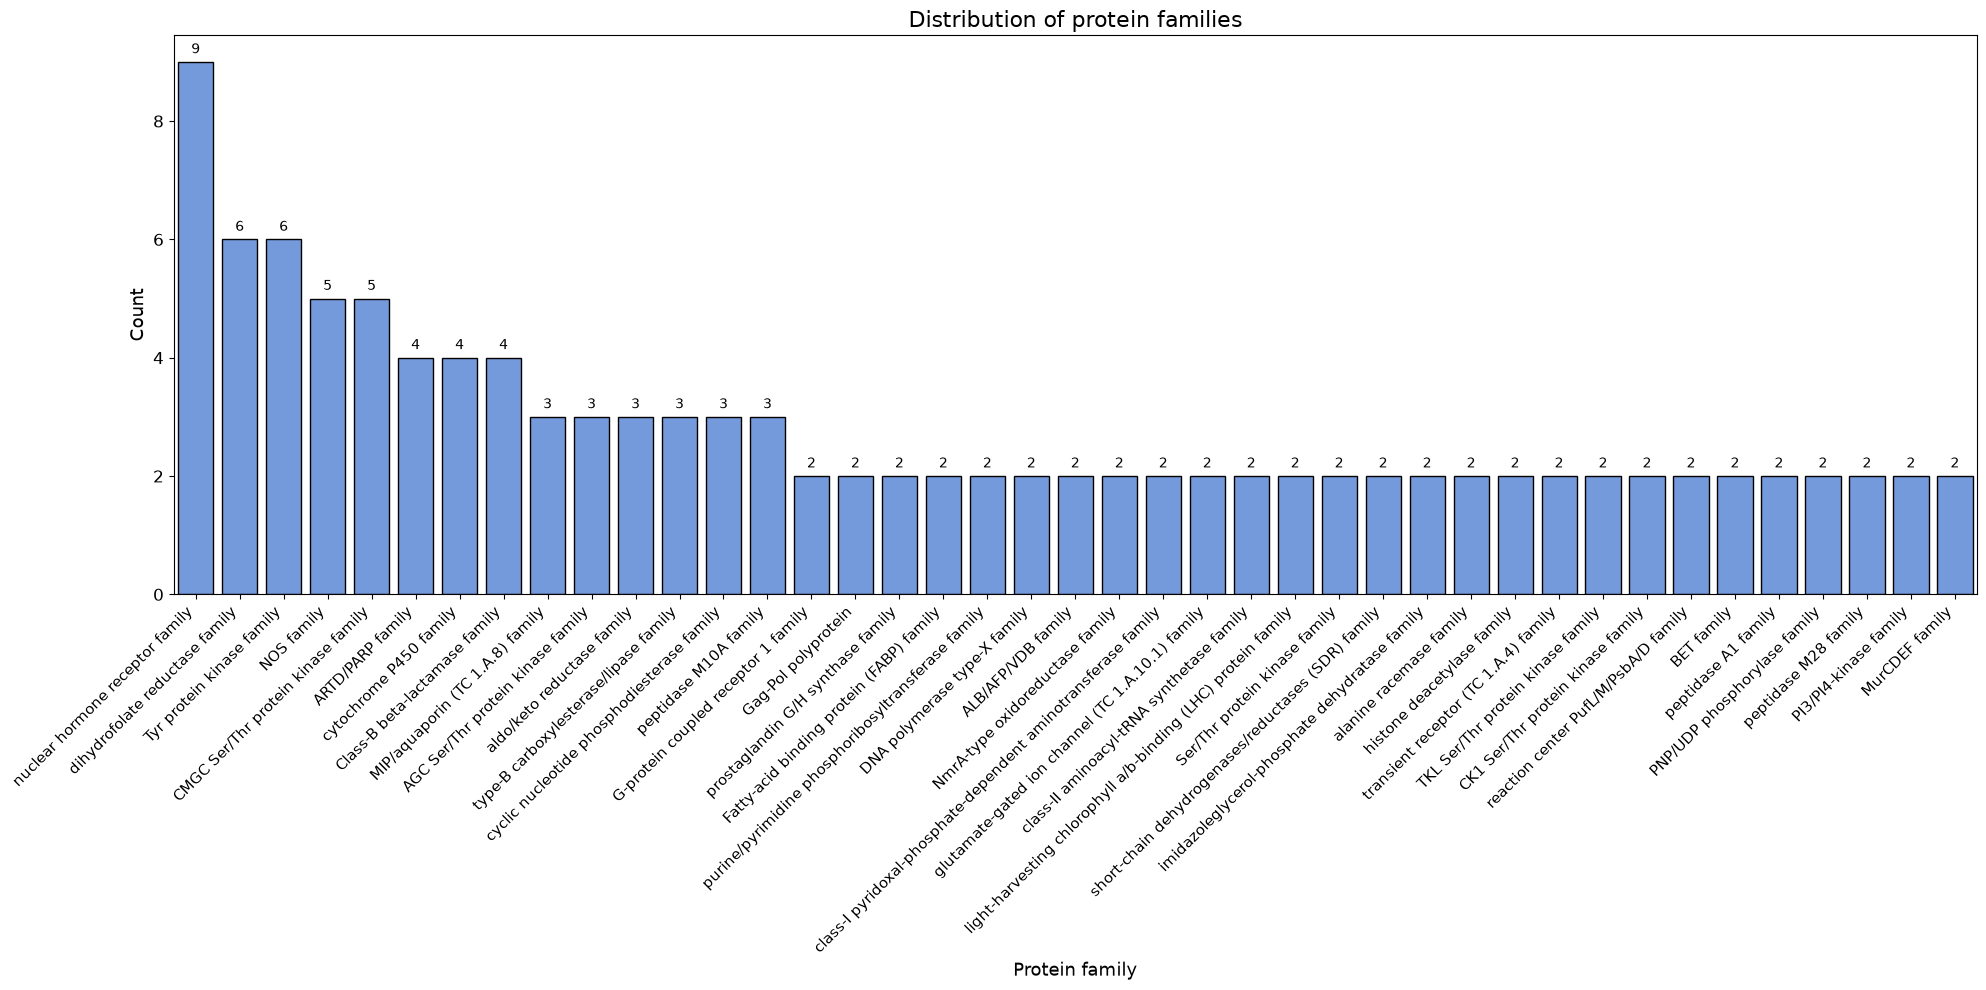

In [4]:
plot_distribution(
    df_fam_sim_annotated['protein_family_sim_str'].apply(stringify_entries),
    title="Distribution of protein families",
    xlabel="Protein family",
    ylabel="Count",
    top_n=41
)

Distribution of the protein family in four curated categories

In [5]:
manual_check_folder = '../Data/Notebook_reproduce_data/Manual_curation'
all_records = []
uniprot_to_family = df_fam_sim_annotated.set_index('uniprot_id')['protein_family_sim_str'].to_dict()

for file in os.listdir(manual_check_folder):
    if file.endswith('.csv') and not 'manualcheck_invalid' in file:
        file_path = os.path.join(manual_check_folder, file)
        df = pd.read_csv(file_path, delimiter='\t')
        df_non4letter_title = df[df['Title'].astype(str).str.len() != 4]
        grouped = df_non4letter_title.groupby('group')
        for group_name, group_df in grouped:
            for idx, row in group_df.iterrows():
                label = row.get('category_manual_check', None)
                ids = row['ID']
                if pd.notna(ids):
                    if isinstance(ids, str) and ids.startswith('[') and ids.endswith(']'):
                        try:
                            ids_list = ast.literal_eval(ids)
                        except Exception:
                            ids_list = []
                    else:
                        ids_list = [ids]
                    for idstr in ids_list:
                        uniprot_id = idstr.split('_')[0]
                        protein_family = uniprot_to_family.get(uniprot_id, None)
                        if protein_family is not None:
                            all_records.append({
                                "group": group_name,
                                "uniprot_id": uniprot_id,
                                "protein_family": protein_family,
                                "manual_label": label
                            })
plot_df = pd.DataFrame(all_records)
plot_df['manual_label'] = plot_df['manual_label'].astype(str)
manual_label_map = {
    "1.2.1": "1.1",
    "1.2.2": "1.2",
    "1.2.3": "1.3",
    "1.1": "2.0"
}
plot_df['manual_label'] = plot_df['manual_label'].replace(manual_label_map)
print(plot_df['manual_label'].value_counts())
plot_df['group'] = plot_df['group'].astype(str)
display(plot_df.head(3))

manual_label
1.1        645
1.3        439
1.2        427
invalid     92
2           82
Name: count, dtype: int64


,group,uniprot_id,protein_family,manual_label
0,{'g000293_4931b3e06d'},F2QVG4,MIP/aquaporin (TC 1.A.8) family,2
1,{'g000293_4931b3e06d'},F2QVG4,MIP/aquaporin (TC 1.A.8) family,2
2,{'g000293_4931b3e06d'},F2QVG4,MIP/aquaporin (TC 1.A.8) family,2


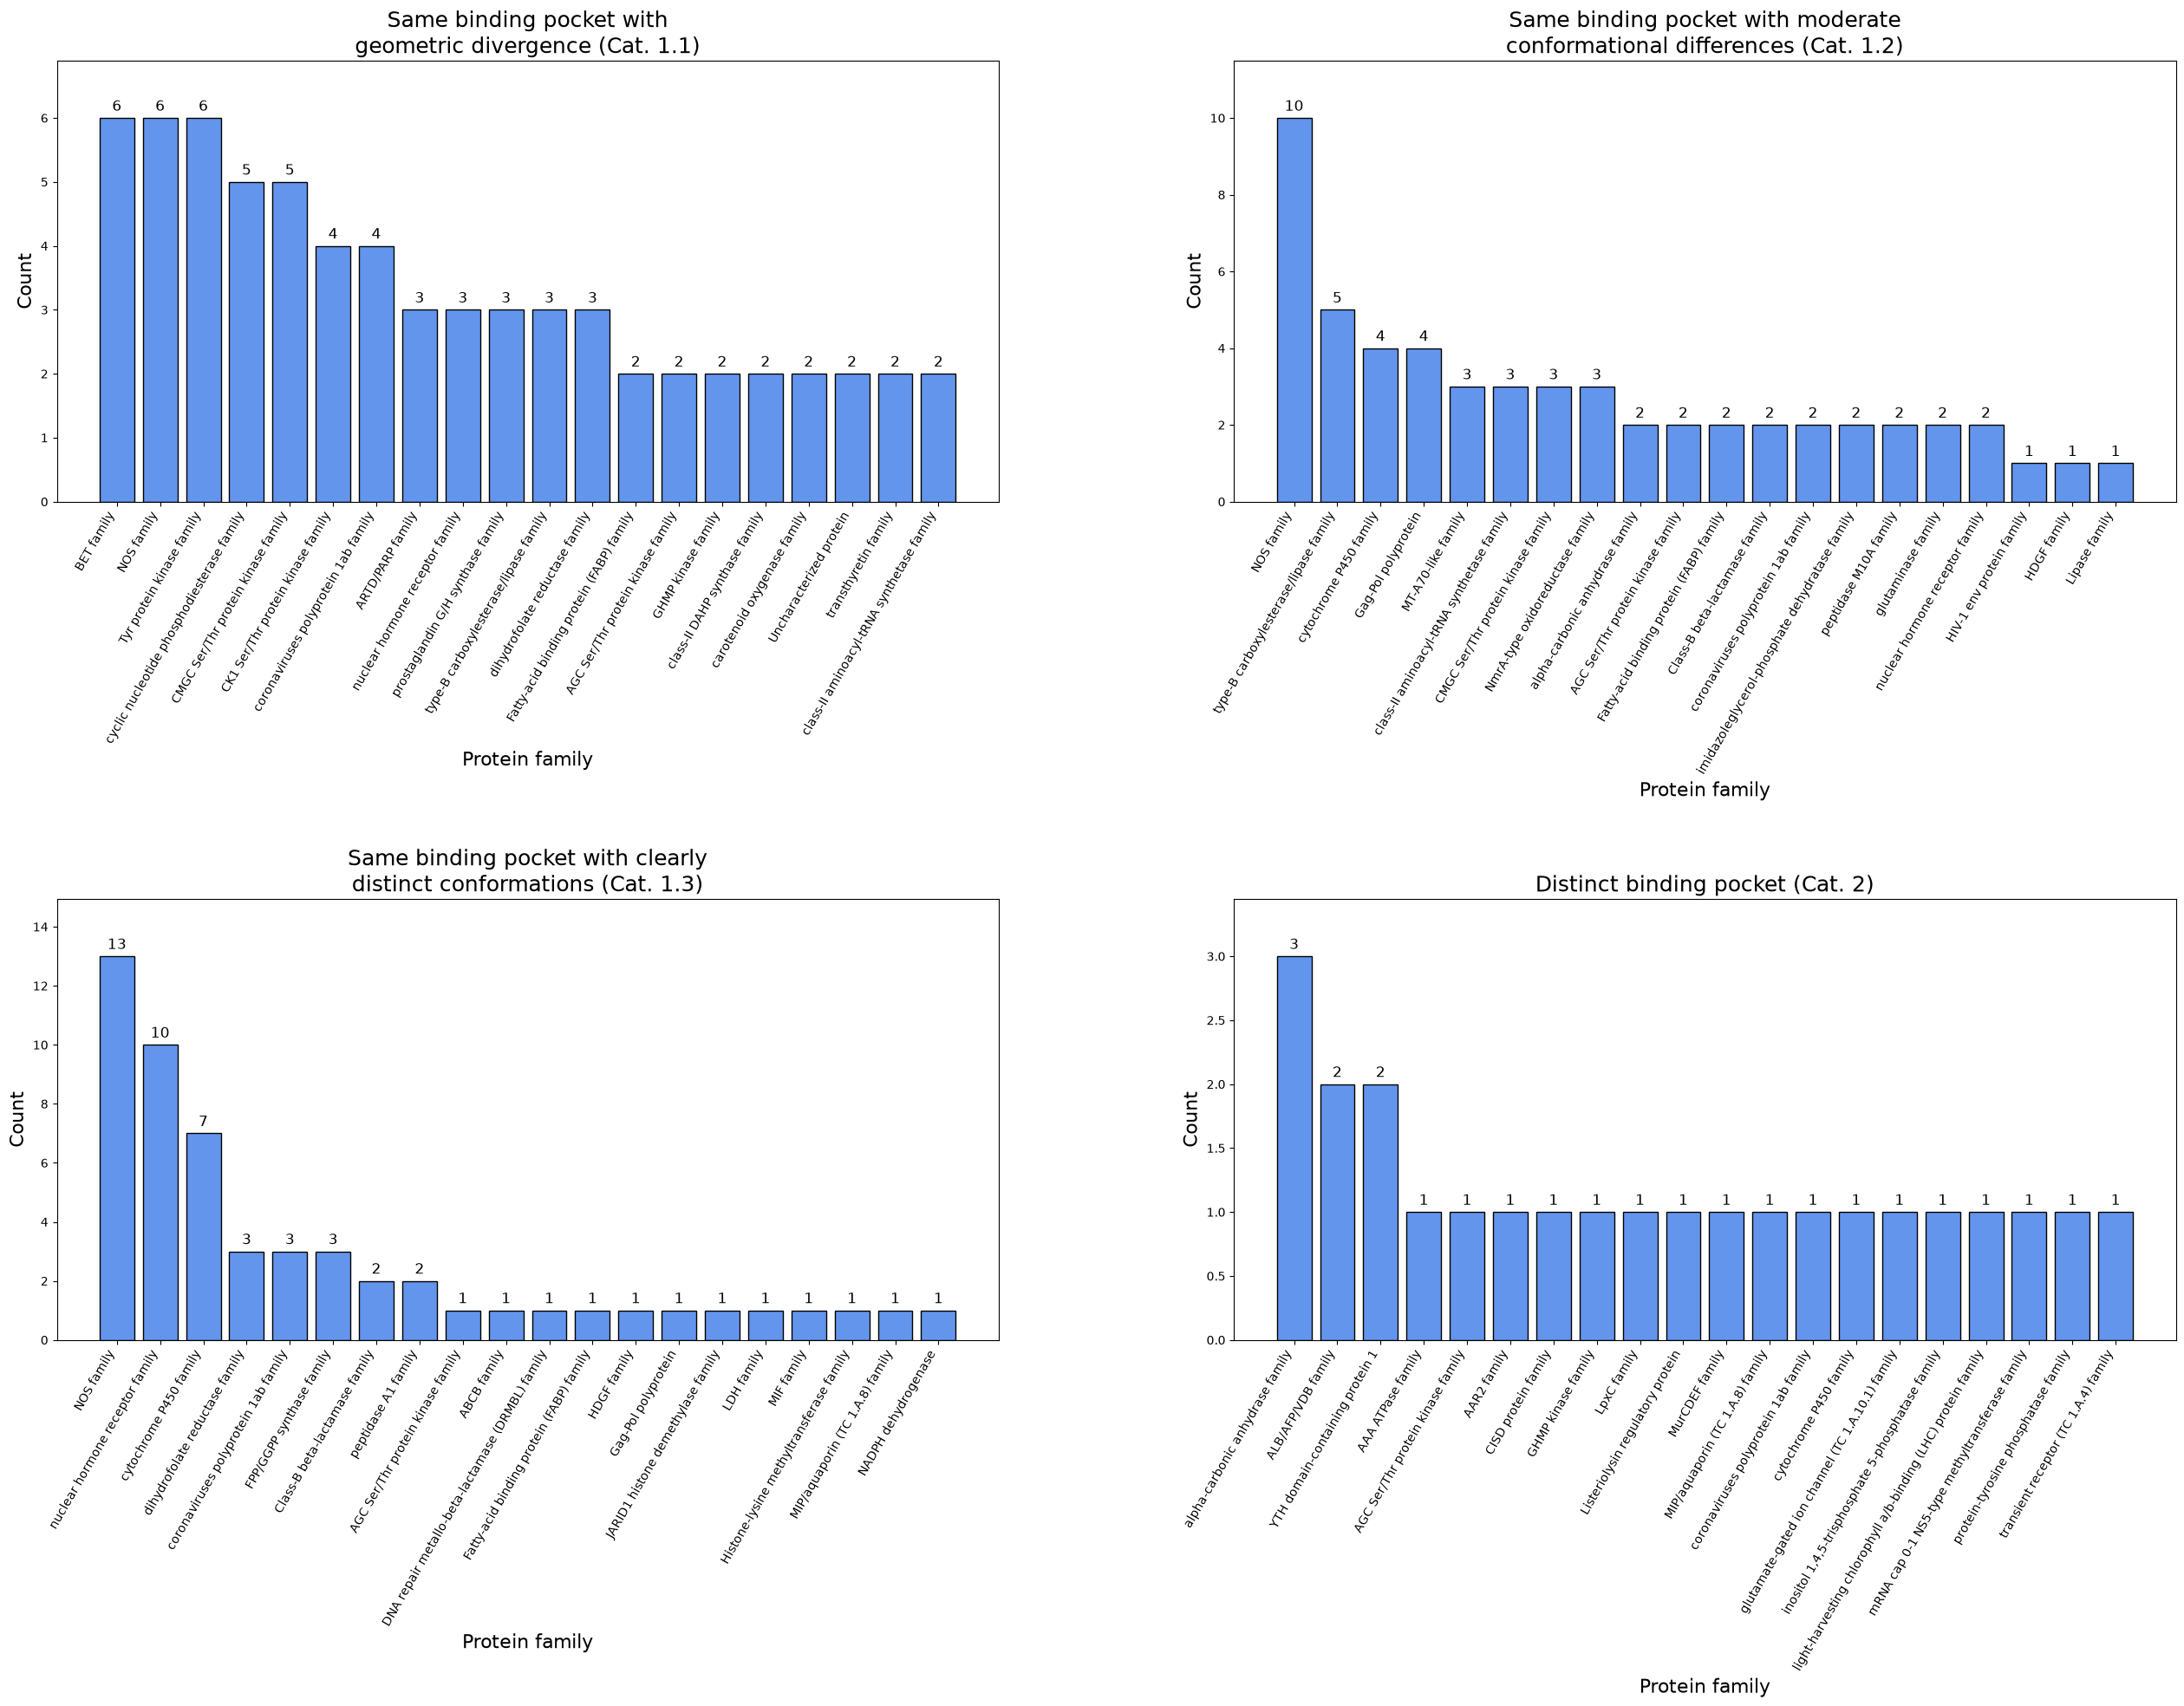

In [6]:
category_label_map = {
    "1.1": "Same binding pocket with\ngeometric divergence (Cat. 1.1)",
    "1.2": "Same binding pocket with moderate\nconformational differences (Cat. 1.2)",
    "1.3": "Same binding pocket with clearly\ndistinct conformations (Cat. 1.3)",
    "2": "Distinct binding pocket (Cat. 2)",
}

codes_in_data = [x for x in plot_df["manual_label"].dropna().unique()]
codes_in_data_sorted = [code for code in ["1.1", "1.2", "1.3", "2"] if code in codes_in_data]
pretty_labels_sorted = [category_label_map.get(code, code) for code in codes_in_data_sorted]

# Adjusted parameters
fig_width = 26
fig_height = 18
title_fontsize = 18
label_fontsize = 16
tick_fontsize = 10
bar_text_fontsize = 12
top_n = 20  # Number to plot per category

if len(codes_in_data_sorted) == 0:
    print("No data to plot for protein family vs. manual label (no categories found).")
else:
    n_rows, n_cols = 2, 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
    axes = axes.flatten()
    for ax, code in zip(axes, codes_in_data_sorted):
        df_cat = plot_df[plot_df["manual_label"] == code]
        group_counts = (
            df_cat.groupby("protein_family")["group"]
            .nunique()
            .sort_values(ascending=False)
            .head(top_n)
        )
        x_vals = group_counts.index.tolist()
        y_vals = group_counts.values
        ax.bar(x_vals, y_vals, color="cornflowerblue", edgecolor="black")
        ax.set_title(category_label_map.get(code, code), fontsize=title_fontsize)
        ax.set_xlabel("Protein family", fontsize=label_fontsize)
        ax.set_ylabel("Count", fontsize=label_fontsize)
        ax.set_xticks(range(len(x_vals)))
        ax.set_xticklabels(x_vals, rotation=60, fontsize=tick_fontsize, ha='right')
        ax.set_ylim(0, max(y_vals) * 1.15 if len(y_vals) > 0 else 1)
        for idx2, value in enumerate(y_vals):
            ax.text(
                idx2,
                value + (max(y_vals) * 0.01 if value > 0 else 0.01),
                str(value),
                ha='center',
                va='bottom',
                fontsize=bar_text_fontsize,
            )
        ax.tick_params(axis='y', labelsize=tick_fontsize)
    for j in range(len(codes_in_data_sorted), n_rows * n_cols):
        fig.delaxes(axes[j])
    fig.subplots_adjust(hspace=0.9, wspace=0.25, top=0.94, bottom=0.12, left=0.04, right=0.98)
    plt.show()

# Distribution of three complementary features in the dataset

In [7]:
feature_table = pd.read_csv("../Data/Notebook_reproduce_data/feature_table.csv")
print(feature_table.columns)
display(feature_table.head(3))

Index(['info_file', 'n_structures', 'n_m0_structures', 'n_m1_structures',
       'n_missing_or_unreadable_sdf', 'atom_count_unique_values',
       'atom_count_by_file', 'atom_count_missing_files',
       'atom_count_inconsistent_files', 'closest_cross_tag_file_a',
       'closest_cross_tag_file_b', 'closest_cross_tag_rmsd_A',
       'closest_cross_tag_similarity', 'closest_cross_tag_silirid_a',
       'closest_cross_tag_silirid_b', 'similarity_metric',
       'silirid_vector_length', 'silirid_count_cap'],
      dtype='str')


,info_file,n_structures,n_m0_structures,n_m1_structures,n_missing_or_unreadable_sdf,atom_count_unique_values,atom_count_by_file,atom_count_missing_files,atom_count_inconsistent_files,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,similarity_metric,silirid_vector_length,silirid_count_cap
0,g000001_inchi_b55a025257_inconsistent.csv,6,4,2,0,"21,23,25,31,32",interaction_7pql_80S_A_301_m0.tsv=23; interact...,NaN,interaction_7pql_80S_A_301_m0.tsv; interaction...,NaN,NaN,NaN,NaN,NaN,NaN,structure_silirid_similarity,160,3
1,g000013_inchi_cb46fef414_inconsistent.csv,7,5,2,0,20,interaction_5tiw_OAQ_A_302_m0.tsv=20; interact...,NaN,NaN,interaction_6b52_OAQ_A_302_m0.tsv,interaction_5tix_OQR_B_302_m1.tsv,3.218487,0.722222,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3
2,g000045_inchi_359154acb2_inconsistent.csv,13,12,1,0,27,interaction_5bk7_EQJ_A_400_m0.tsv=27; interact...,NaN,NaN,interaction_6c92_EQJ_A_401_m0.tsv,interaction_5dj3_5DK_C_500_m1.tsv,2.537710,0.500000,"0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,3,0,...","0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,2,0,...",structure_silirid_similarity,160,3


In [8]:
def extract_group_key(info_file):
    parts = str(info_file).split('_')
    if len(parts) >= 3:
        return f"{{'{parts[0]}_{parts[2]}'}}"
    return None

# Create a mapping from plot_df group to manual_label (as string key)
group_to_manual = plot_df.set_index('group')['manual_label'].to_dict()

feature_table['manual_label'] = feature_table['info_file'].apply(
    lambda x: group_to_manual.get(extract_group_key(x), None)
)

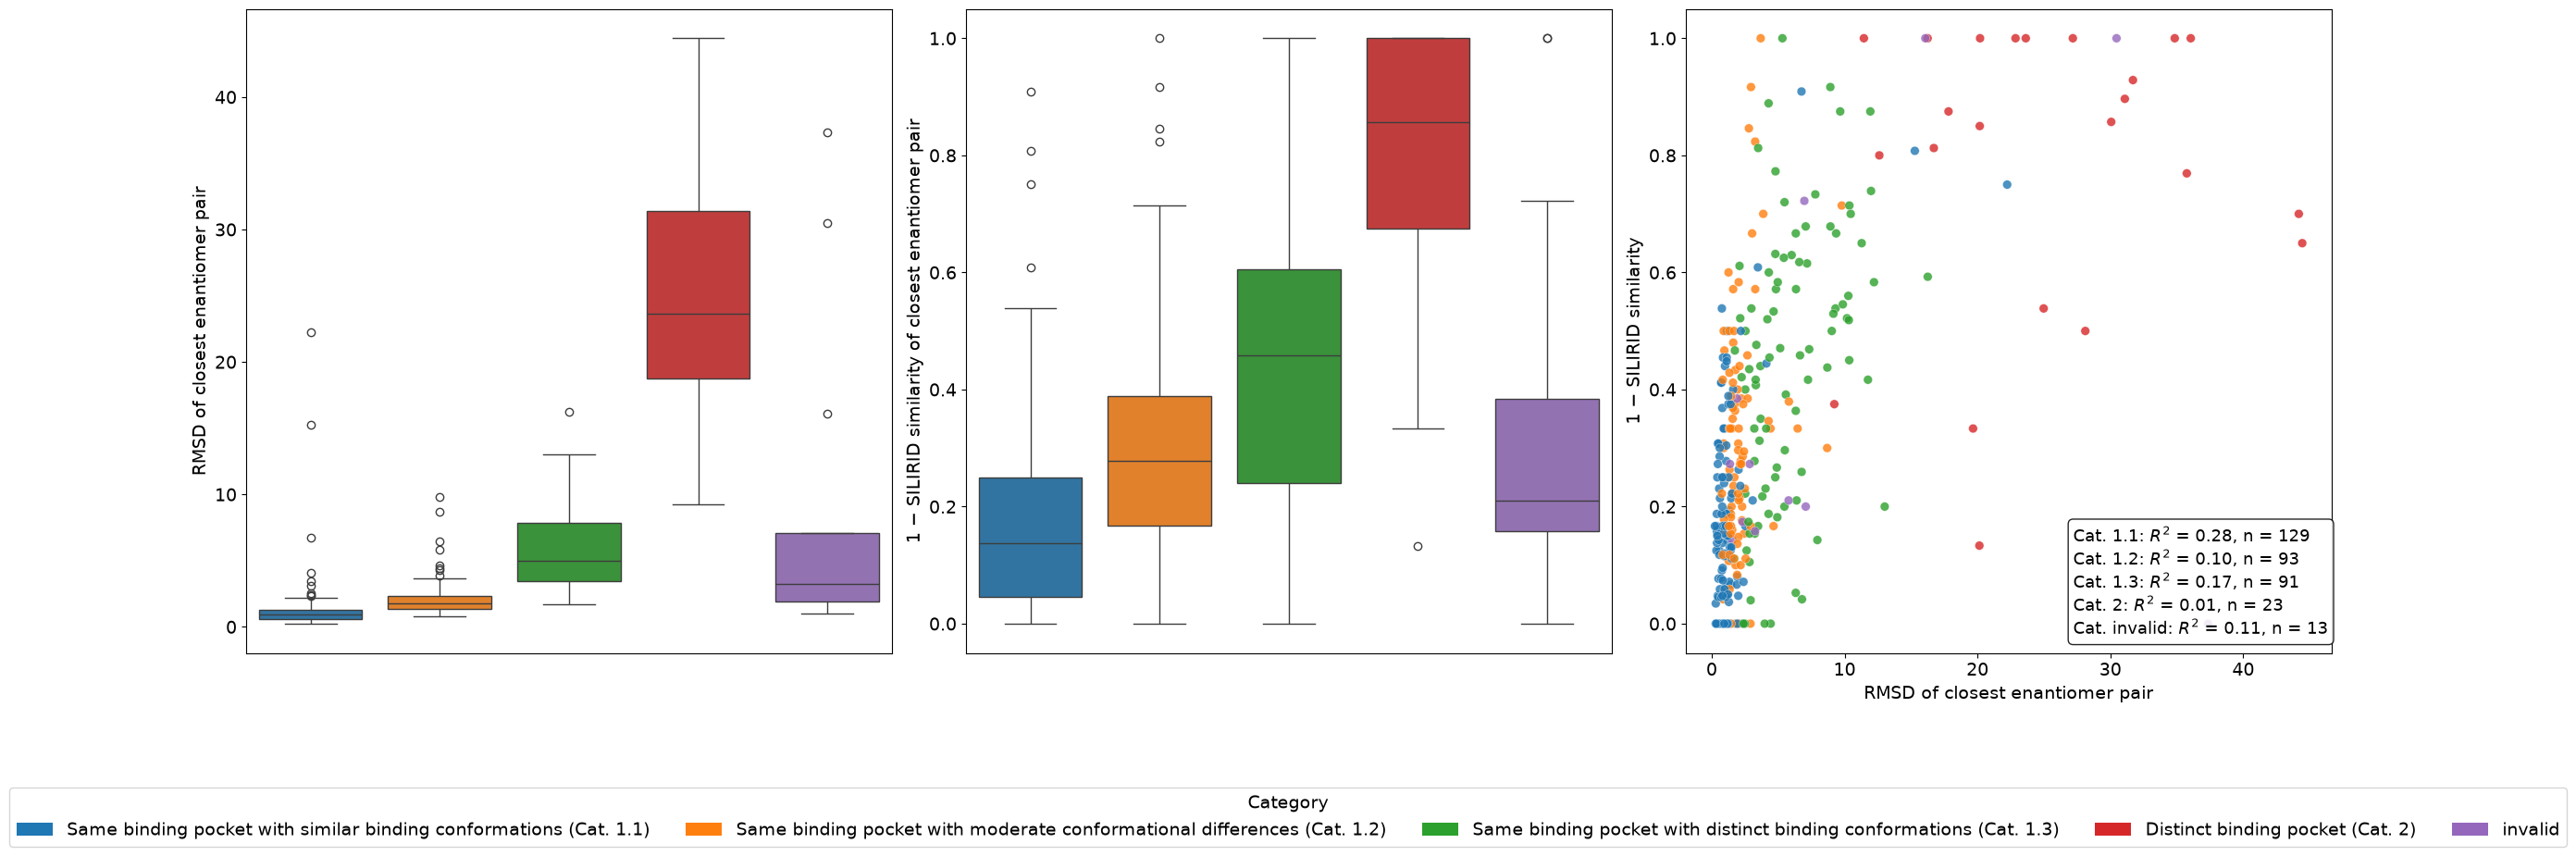

In [9]:

feature_table["manual_label"] = (
    feature_table["manual_label"].astype(str)
)
feature_table["closest_cross_tag_distance"] = (
    1 - feature_table["closest_cross_tag_similarity"]
)
labels_sorted = sorted(
    feature_table["manual_label"].dropna().unique(),
    key=lambda x: str(x)
)

category_label_map = {
    "1.1": "Same binding pocket with similar binding conformations (Cat. 1.1)",
    "1.2": "Same binding pocket with moderate conformational differences (Cat. 1.2)",
    "1.3": "Same binding pocket with distinct binding conformations (Cat. 1.3)",
    "2": "Distinct binding pocket (Cat. 2)",
}

palette_colors = sns.color_palette(
    "tab10" if len(labels_sorted) <= 10 else "tab20",
    n_colors=len(labels_sorted)
)

# Change the last color to a purple-ish color instead of red
if len(palette_colors) > 0:
    # Replace the last color
    palette_colors = list(palette_colors)
    # Use a pleasant purple, e.g., matplotlib 'purple'
    palette_colors[-1] = (148/255, 103/255, 189/255)  # matplotlib tab10 purple

label_to_color = dict(
    zip(labels_sorted, palette_colors)
)
boxplot_columns = [
    (
        "closest_cross_tag_rmsd_A",
        "RMSD of closest enantiomer pair"
    ),
    (
        "closest_cross_tag_distance",
        "1 − SILIRID similarity of closest enantiomer pair"
    ),
]
label_fontsize = 14
tick_fontsize = 14
legend_fontsize = 14
title_fontsize = 17
fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 6)
)
legend_handles = None
for ax, (y, ylabel) in zip(
    axes[:2],
    boxplot_columns
):
    sns.boxplot(
        data=feature_table,
        x="manual_label",
        y=y,
        hue="manual_label",
        order=labels_sorted,
        hue_order=labels_sorted,
        palette=label_to_color,
        dodge=False,
        showfliers=True,
        ax=ax,
        legend=False,
    )
    ax.set_xlabel(
        "",
        fontsize=label_fontsize
    )
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_ylabel(
        ylabel,
        fontsize=label_fontsize
    )
    ax.tick_params(
        axis="y",
        labelsize=tick_fontsize
    )
    if ax is axes[0]:
        legend_handles = [
            Patch(
                facecolor=label_to_color[code],
                label=category_label_map.get(
                    str(code),
                    str(code)
                )
            )
            for code in labels_sorted
        ]
plot_df = feature_table[
    [
        "closest_cross_tag_rmsd_A",
        "closest_cross_tag_distance",
        "manual_label"
    ]
].copy()
pretty_names = {
    "closest_cross_tag_rmsd_A":
        "RMSD of closest enantiomer pair",

    "closest_cross_tag_distance":
        "1 − SILIRID similarity",

    "manual_label":
        "Manual Label"
}
plot_df = plot_df.rename(
    columns=pretty_names
)
regression_results = {}
for label in labels_sorted:
    class_df = plot_df[
        plot_df["Manual Label"] == str(label)
    ].dropna(
        subset=[
            "RMSD of closest enantiomer pair",
            "1 − SILIRID similarity"
        ]
    )
    x = class_df[
        "RMSD of closest enantiomer pair"
    ]
    y = class_df[
        "1 − SILIRID similarity"
    ]
    result = linregress(
        x,
        y
    )
    regression_results[str(label)] = {
        "r": result.rvalue,
        "r2": result.rvalue ** 2,
        "slope": result.slope,
        "intercept": result.intercept,
        "p_value": result.pvalue,
        "n": len(class_df)
    }
ax3 = axes[2]
sns.scatterplot(
    data=plot_df,
    x="RMSD of closest enantiomer pair",
    y="1 − SILIRID similarity",
    hue="Manual Label",
    hue_order=labels_sorted,
    palette=label_to_color,
    alpha=0.8,
    s=48,
    edgecolor="w",
    linewidth=0.3,
    ax=ax3,
    legend=False,
)
stats_lines = []
for label in labels_sorted:
    results = regression_results[str(label)]
    if results["r2"] is not None:
        stats_lines.append(
            f"Cat. {label}: "
            f"$R^2$ = {results['r2']:.2f}, "
            f"n = {results['n']}"
        )
    else:
        stats_lines.append(
            f"Cat. {label}: "
            f"insufficient data "
            f"(n = {results['n']})"
        )
stats_text = "\n".join(
    stats_lines
)
ax3.text(
    0.60,
    0.20,
    stats_text,
    transform=ax3.transAxes,
    fontsize=13,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    )
)

ax3.set_xlabel(
    "RMSD of closest enantiomer pair",
    fontsize=label_fontsize
)
ax3.set_ylabel(
    "1 − SILIRID similarity",
    fontsize=label_fontsize
)
ax3.tick_params(
    axis="x",
    labelsize=tick_fontsize
)
ax3.tick_params(
    axis="y",
    labelsize=tick_fontsize
)

leg = None
if legend_handles is not None:

    leg = fig.legend(
        handles=legend_handles,
        title="Category",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=len(labels_sorted),
        fontsize=legend_fontsize,
        title_fontsize=legend_fontsize,
    )

plt.tight_layout(
    rect=[0, 0.2, 1, 1.5]
)

extra_artists = (
    [leg]
    if leg is not None
    else None
)

plt.show()

In [10]:
enantiomer_structures = '../Data/Notebook_reproduce_data/filtered_enantiomer_with_uniprot_UniProtID_updated.sdf'
manual_check_folder = '../Data/Notebook_reproduce_data/Manual_curation'
all_matched_records = []
for file in os.listdir(manual_check_folder):
    if file.endswith('.csv') and not 'manualcheck_invalid' in file:
        file_path = os.path.join(manual_check_folder, file)
        df = pd.read_csv(file_path, delimiter='\t')
        df_non4letter_title = df[df['Title'].astype(str).str.len() != 4]
        grouped = df_non4letter_title.groupby('group')
        for group_name, group_df in grouped:
            for idx, row in group_df.iterrows():
                ids = row['ID']
                if pd.notna(ids):
                    if isinstance(ids, str) and ids.startswith('[') and ids.endswith(']'):
                        try:
                            ids_list = ast.literal_eval(ids)
                        except Exception:
                            ids_list = []
                    else:
                        ids_list = [ids]
                    for pdb_item in ids_list:
                        matched_record = {
                            'group': group_name,
                            'category': row['category_manual_check'],
                            'pdb_item': pdb_item,
                            'pdb_code': None,
                            'ligand_name': None,
                            'matched': False,
                            'pdbbind_info': None,
                        }
                        if isinstance(pdb_item, str) and '_' in pdb_item:
                            split_pdb = pdb_item.split('_')
                            if len(split_pdb) >= 3:
                                pdb_code = split_pdb[1].strip().lower()
                                ligand_name = split_pdb[2].strip()
                                m_layer = split_pdb[5].strip()
                                matched_record['pdb_code'] = pdb_code
                                matched_record['ligand_name'] = ligand_name
                                matched_record['m_layer'] = m_layer
                            all_matched_records.append(matched_record)
matched_df = pd.DataFrame(all_matched_records)
matched_df.head(10)

,group,category,pdb_item,pdb_code,ligand_name,matched,pdbbind_info,m_layer
0,{'g000293_4931b3e06d'},2,F2QVG4_2w1p_BOG_A_1275_m1,2w1p,BOG,False,None,m1
1,{'g000293_4931b3e06d'},2,F2QVG4_2w1p_BOG_A_1276_m1,2w1p,BOG,False,None,m1
2,{'g000293_4931b3e06d'},2,F2QVG4_2w1p_BOG_A_1277_m1,2w1p,BOG,False,None,m1
3,{'g000293_4931b3e06d'},2,F2QVG4_2w1p_BOG_A_1274_m1,2w1p,BOG,False,None,m1
4,{'g000293_4931b3e06d'},2,F2QVG4_2w2e_BOG_A_1274_m1,2w2e,BOG,False,None,m1
5,{'g000293_4931b3e06d'},2,F2QVG4_2w2e_BOG_A_1276_m1,2w2e,BOG,False,None,m1
6,{'g000293_4931b3e06d'},2,F2QVG4_2w2e_BOG_A_1278_m1,2w2e,BOG,False,None,m1
7,{'g000293_4931b3e06d'},2,F2QVG4_2w2e_BOG_A_1279_m0,2w2e,BOG,False,None,m0
8,{'g000293_4931b3e06d'},2,F2QVG4_2w2e_BOG_A_1275_m1,2w2e,BOG,False,None,m1
9,{'g000293_4931b3e06d'},2,F2QVG4_3zoj_BOG_A_1275_m1,3zoj,BOG,False,None,m1


In [11]:
enantiomer_mols = {}
SDMolSupplier_enantiomers = Chem.SDMolSupplier(enantiomer_structures)
for mol in SDMolSupplier_enantiomers:
    if mol is not None and mol.HasProp("_Name"):
        enantiomer_mols[mol.GetProp("_Name")] = mol

represenetative_enantiomer_mols = []
visited_groups = set()
for idx, (identifier, group, category) in enumerate(zip(matched_df['pdb_item'],
                                                    matched_df['group'], matched_df['category'])):
    if group in visited_groups:
        continue  # Skip if we've already collected an entry for this group
    parts = identifier.split('_')
    enantiomer_identifier = '_'.join(parts[1:-1])
    mol = enantiomer_mols.get(enantiomer_identifier, None)
    if mol is not None:
        represenetative_enantiomer_mols.append((enantiomer_identifier, mol, group, category))
        visited_groups.add(group)
    else:
        print(f"No matching structure found for: {enantiomer_identifier}")

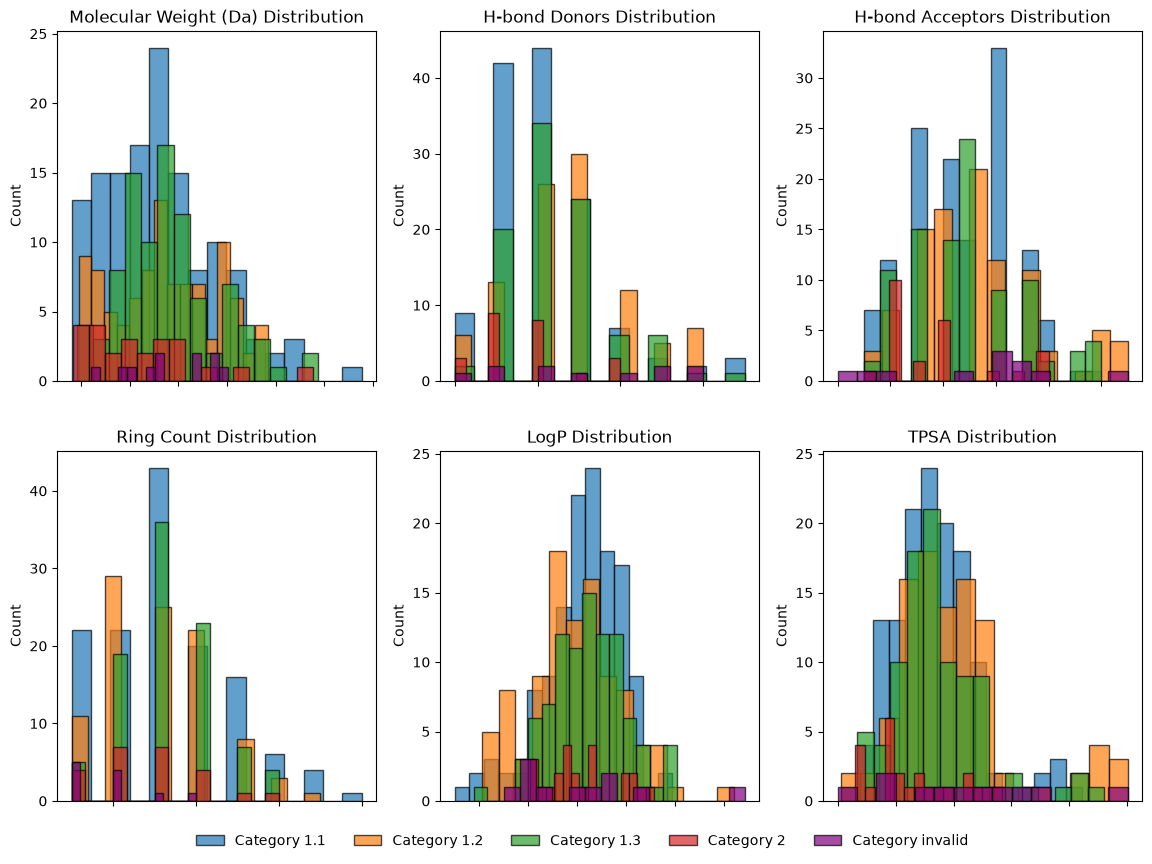

In [12]:
def remap_category(cat):
    cat = str(cat)
    if cat == "1.2.1":
        return "1.1"
    elif cat == "1.2.2":
        return "1.2"
    elif cat == "1.2.3":
        return "1.3"
    elif cat == "1.1":
        return "2.0"
    else:
        return cat

unique_cats = sorted(set(remap_category(category) for _, _, _, category in represenetative_enantiomer_mols))

# Set last color to purple in the palette (late = purple)
palette_colors = sns.color_palette("tab10", n_colors=len(unique_cats))
if len(palette_colors) > 0:
    palette_colors = list(palette_colors)
    palette_colors[-1] = (0.5, 0.0, 0.5)  # Replace last color with purple (RGB normalized)

cat_color_dict = dict(zip(unique_cats, palette_colors))

mol_weights = []
hbd_list = []
hba_list = []
ring_count_list = []
logp_list = []
tpsa_list = []
categories = []

for identifier, mol, group, category in represenetative_enantiomer_mols:
    mol_weights.append(Descriptors.MolWt(mol))
    hbd_list.append(Descriptors.NumHDonors(mol))
    hba_list.append(Descriptors.NumHAcceptors(mol))
    ring_count_list.append(Descriptors.RingCount(mol))
    logp_list.append(Descriptors.MolLogP(mol))
    tpsa_list.append(Descriptors.TPSA(mol))
    cat_str = remap_category(category)
    categories.append(cat_str)

df = pd.DataFrame({
    'MolecularWeight': mol_weights,
    'HBDonors': hbd_list,
    'HBAcceptors': hba_list,
    'RingCount': ring_count_list,
    'LogP': logp_list,
    'TPSA': tpsa_list,
    'Category': categories
})
properties = [
    ('MolecularWeight', 'Molecular Weight (Da)'),
    ('HBDonors', 'H-bond Donors'),
    ('HBAcceptors', 'H-bond Acceptors'),
    ('RingCount', 'Ring Count'),
    ('LogP', 'LogP'),
    ('TPSA', 'TPSA')
]
num_properties = len(properties)
ncols = 3
nrows = (num_properties + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 5))
axes = axes.flatten()

handles_labels_set = False
handles = None
labels = None
for i, (prop, label) in enumerate(properties):
    if i >= len(axes):
        break
    ax = axes[i]
    local_handles = []
    local_labels = []
    for j, cat in enumerate(unique_cats):
        prop_values = df[df['Category'] == cat][prop]
        n, bins, patches = ax.hist(
            prop_values, bins=15, alpha=0.70, 
            label=f'Category {cat}',
            color=cat_color_dict[cat], 
            edgecolor='black'
        )
        if not handles_labels_set and len(patches) > 0:
            local_handles.append(patches[0])
            local_labels.append(f'Category {cat}')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Distribution')
    ax.set_xticklabels([])  # Remove x ticks label
    if not handles_labels_set:
        handles = local_handles
        labels = local_labels
        handles_labels_set = True
for j in range(num_properties, len(axes)):
    fig.delaxes(axes[j])
if handles is not None and labels is not None:
    fig.legend(
        handles, labels,
        loc='lower center', bbox_to_anchor=(0.5, 0.05), ncol=len(labels), frameon=False
    )
plt.show()

# SILIRID quantification

In [13]:
silirid_fingerprint_slot = pd.read_csv('../Data/Notebook_reproduce_data/silirid_fingerprint_slots.csv')
display(silirid_fingerprint_slot.head(5))

,slot_index,amino_acid,feature_type
0,0,ALA,HYDROPHOBIC
1,1,ALA,AROMATIC
2,2,ALA,NEGATIVE_IONIZABLE
3,3,ALA,POSITIVE_IONIZABLE
4,4,ALA,H_BOND_DONOR


Pharmacophore examples searching

In [14]:
top_five = (
    feature_table[feature_table['manual_label'] == '1.1']
    .sort_values(by='closest_cross_tag_similarity', ascending=False)
    .head(5)
)
top_five

,info_file,n_structures,n_m0_structures,n_m1_structures,n_missing_or_unreadable_sdf,atom_count_unique_values,atom_count_by_file,atom_count_missing_files,atom_count_inconsistent_files,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,similarity_metric,silirid_vector_length,silirid_count_cap,manual_label,closest_cross_tag_distance
11,g000144_inchi_e41f15b5ba_inconsistent.csv,4,1,3,0,29,interaction_7km7_WPD_A_202_m1.tsv=29; interact...,NaN,NaN,interaction_7km9_WPJ_A_202_m0.tsv,interaction_7km7_WPD_A_202_m1.tsv,0.596462,1.0,"0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.1,0.0
18,g000212_inchi_2f85649d80_inconsistent.csv,2,1,1,0,15,interaction_7yy8_3IL_B_201_m0.tsv=15; interact...,NaN,NaN,interaction_7yy8_3IL_B_201_m0.tsv,interaction_7yy8_4Z9_C_201_m1.tsv,0.910342,1.0,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.1,0.0
48,g000444_inchi_c672a921c7_inconsistent.csv,9,4,5,0,23,interaction_6vgl_RXT_C_1201_m1.tsv=23; interac...,NaN,NaN,interaction_6vsn_RG4_D_1201_m0.tsv,interaction_6vnk_RXT_D_1201_m1.tsv,0.535079,1.0,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.1,0.0
52,g000448_inchi_d463a70235_consistent.csv,2,1,1,0,25,interaction_5z8g_99L_A_201_m1.tsv=25; interact...,NaN,NaN,interaction_5z8r_99O_A_201_m0.tsv,interaction_5z8g_99L_A_201_m1.tsv,0.491896,1.0,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...",structure_silirid_similarity,160,3,1.1,0.0
99,g000631_inchi_fc37cae7c4_inconsistent.csv,2,1,1,0,15,interaction_7fc4_IBP_A_200_m0.tsv=15; interact...,NaN,NaN,interaction_7fc4_IBP_A_200_m0.tsv,interaction_8zci_IZP_A_200_m1.tsv,1.799828,1.0,"0,0,0,0,0,0,0,0,0,3,3,0,0,2,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,3,3,0,0,2,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.1,0.0


In [15]:
middle_five = (
    feature_table[feature_table['manual_label'] == '1.1']
    .sort_values(by='closest_cross_tag_similarity', ascending=False)
)

middle_index = len(middle_five) // 2
start = max(0, middle_index - 2)
end = start + 5

middle_five_subset = middle_five.iloc[start:end]
middle_five_subset

,info_file,n_structures,n_m0_structures,n_m1_structures,n_missing_or_unreadable_sdf,atom_count_unique_values,atom_count_by_file,atom_count_missing_files,atom_count_inconsistent_files,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,similarity_metric,silirid_vector_length,silirid_count_cap,manual_label,closest_cross_tag_distance
102,g000643_inchi_7afe262ba5_inconsistent.csv,2,1,1,0,29,interaction_7q1o_9CI_A_605_m0.tsv=29; interact...,NaN,NaN,interaction_7q1o_9CI_A_605_m0.tsv,interaction_7q1p_8UW_A_606_m1.tsv,0.827606,0.862069,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.1,0.137931
186,g001014_inchi_ec8bff652c_inconsistent.csv,2,1,1,0,38,interaction_6q7b_HO5_A_1001_m0.tsv=38; interac...,NaN,NaN,interaction_6q7b_HO5_A_1001_m0.tsv,interaction_6q7e_HMW_A_1001_m1.tsv,0.396353,0.862069,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.1,0.137931
239,g001166_inchi_c0fb4970f3_inconsistent.csv,5,2,3,0,26,interaction_6q90_HFK_B_402_m0.tsv=26; interact...,NaN,NaN,interaction_6q90_HFK_C_402_m0.tsv,interaction_6q91_HFK_C_402_m1.tsv,0.511745,0.857143,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.1,0.142857
13,g000186_inchi_b4715436af_inconsistent.csv,6,2,4,0,31,interaction_7t5z_F6I_B_301_m1.tsv=31; interact...,NaN,NaN,interaction_7t5z_F6I_F_301_m0.tsv,interaction_7t5z_F6I_B_301_m1.tsv,1.183163,0.857143,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.1,0.142857
216,g001054_inchi_5d9ad31d44_inconsistent.csv,2,1,1,0,36,interaction_5vd9_98G_A_601_m1.tsv=36; interact...,NaN,NaN,interaction_5vda_98D_A_601_m0.tsv,interaction_5vd9_98G_A_601_m1.tsv,1.239758,0.850000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...",structure_silirid_similarity,160,3,1.1,0.150000


In [16]:
bottom_five = (
    feature_table[
        (feature_table['manual_label'] == '1.1') &
        (feature_table['closest_cross_tag_similarity'].notna())
    ]
    .sort_values(by='closest_cross_tag_similarity', ascending=True)
    .head(5)
)
bottom_five

,info_file,n_structures,n_m0_structures,n_m1_structures,n_missing_or_unreadable_sdf,atom_count_unique_values,atom_count_by_file,atom_count_missing_files,atom_count_inconsistent_files,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,similarity_metric,silirid_vector_length,silirid_count_cap,manual_label,closest_cross_tag_distance
228,g001101_inchi_d0b8210ed2_inconsistent.csv,2,1,1,0,28,interaction_7oki_VHZ_A_201_m1.tsv=28; interact...,NaN,NaN,interaction_7okj_VHN_A_201_m0.tsv,interaction_7oki_VHZ_A_201_m1.tsv,6.753362,0.090909,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.1,0.909091
291,g001432_inchi_d420efaccc_inconsistent.csv,4,2,2,0,19,interaction_4zhk_A8V_A_606_m0.tsv=19; interact...,NaN,NaN,interaction_4zhk_A8V_A_606_m0.tsv,interaction_4zhk_A9V_A_607_m1.tsv,15.281985,0.192308,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.1,0.807692
246,g001203_inchi_8b3a40b56d_inconsistent.csv,4,1,3,0,"12,21",interaction_4xdk_405_A_608_m0.tsv=21; interact...,NaN,interaction_4xdk_408_C_606_m1.tsv,interaction_4xdk_405_A_608_m0.tsv,interaction_4xdk_408_A_606_m1.tsv,22.231554,0.250000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.1,0.750000
143,g000807_inchi_ef18922c3f_inconsistent.csv,3,1,2,0,"7,14",interaction_1e2i_APS_B_510_m0.tsv=14; interact...,NaN,interaction_1e2i_ARP_A_502_m1.tsv,interaction_1e2i_APS_B_510_m0.tsv,interaction_1e2i_ARP_B_511_m1.tsv,3.472281,0.391304,"0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.1,0.608696
281,g001387_inchi_6be500f3b9_inconsistent.csv,4,3,1,0,23,interaction_9l90_U1C_A_1101_m0.tsv=23; interac...,NaN,NaN,interaction_9l90_U1C_A_1101_m0.tsv,interaction_9l9b_U1C_B_1102_m1.tsv,0.761237,0.461538,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...",structure_silirid_similarity,160,3,1.1,0.538462


In [17]:
silirid_fingerprint_slot['amino_acid_feature'] = silirid_fingerprint_slot['amino_acid'].astype(str) + '_' + silirid_fingerprint_slot['feature_type'].astype(str)
display(silirid_fingerprint_slot.head(5))

,slot_index,amino_acid,feature_type,amino_acid_feature
0,0,ALA,HYDROPHOBIC,ALA_HYDROPHOBIC
1,1,ALA,AROMATIC,ALA_AROMATIC
2,2,ALA,NEGATIVE_IONIZABLE,ALA_NEGATIVE_IONIZABLE
3,3,ALA,POSITIVE_IONIZABLE,ALA_POSITIVE_IONIZABLE
4,4,ALA,H_BOND_DONOR,ALA_H_BOND_DONOR


SILIRID count differences across four categories

For each category, select the five most similar, five middle, and five least similar pairs by `closest_cross_tag_similarity`. Each heatmap row is one pair; each column is one SILIRID slot (amino acid × interaction type). Color is the absolute count difference `|A − B|`.

findfont: Failed to find font weight medium, now using 400.


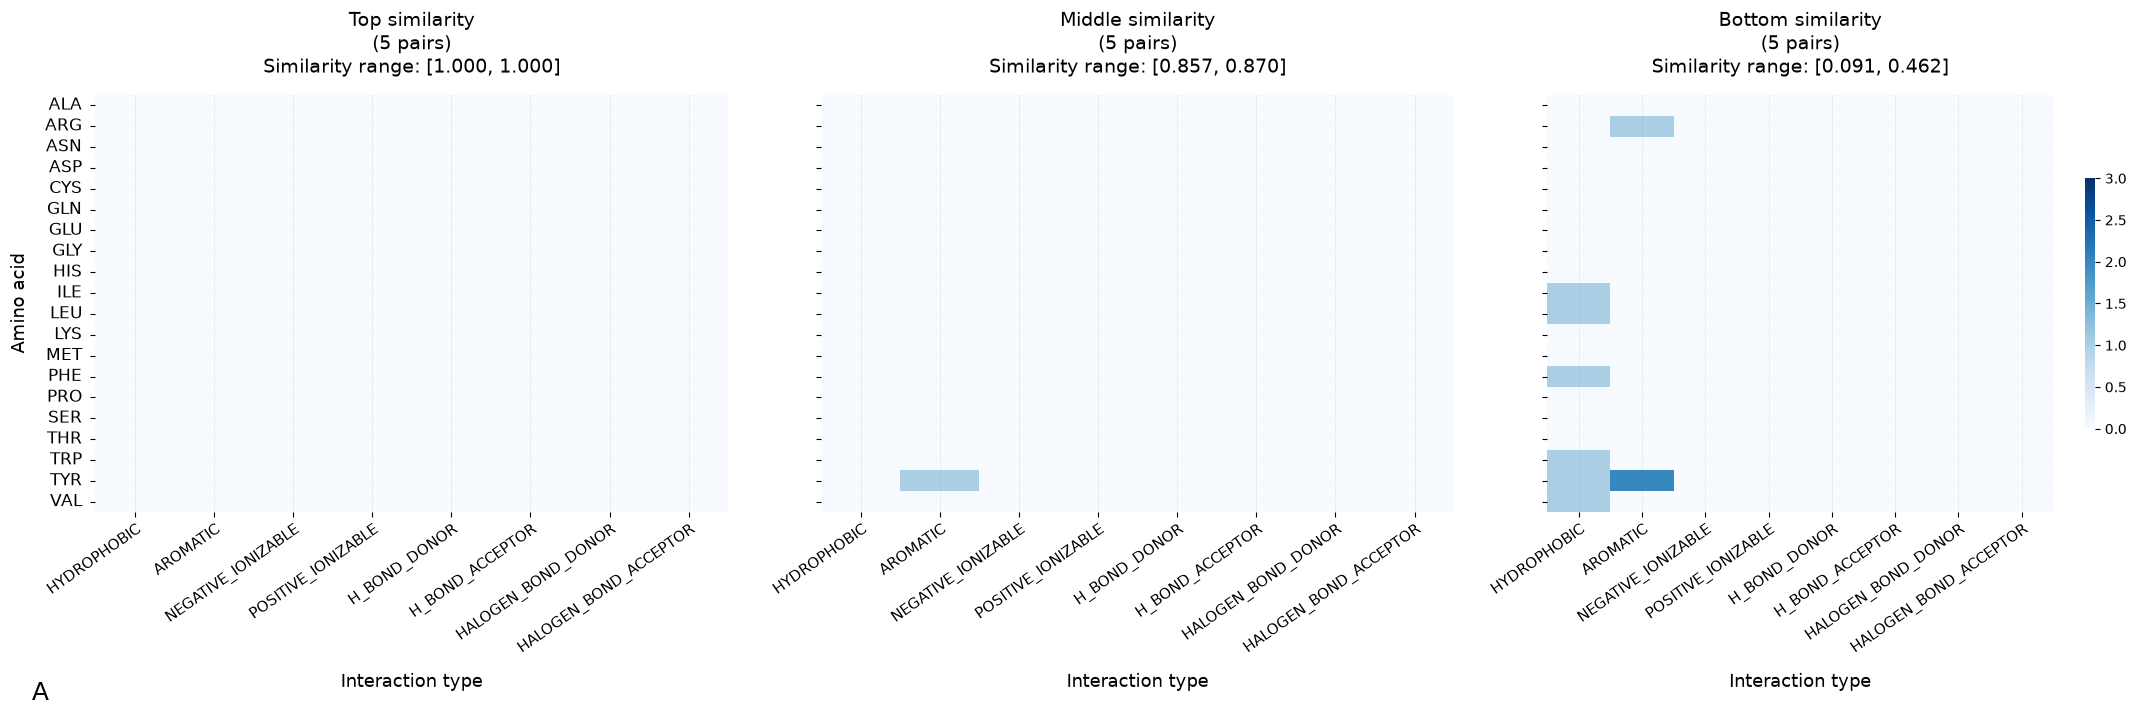

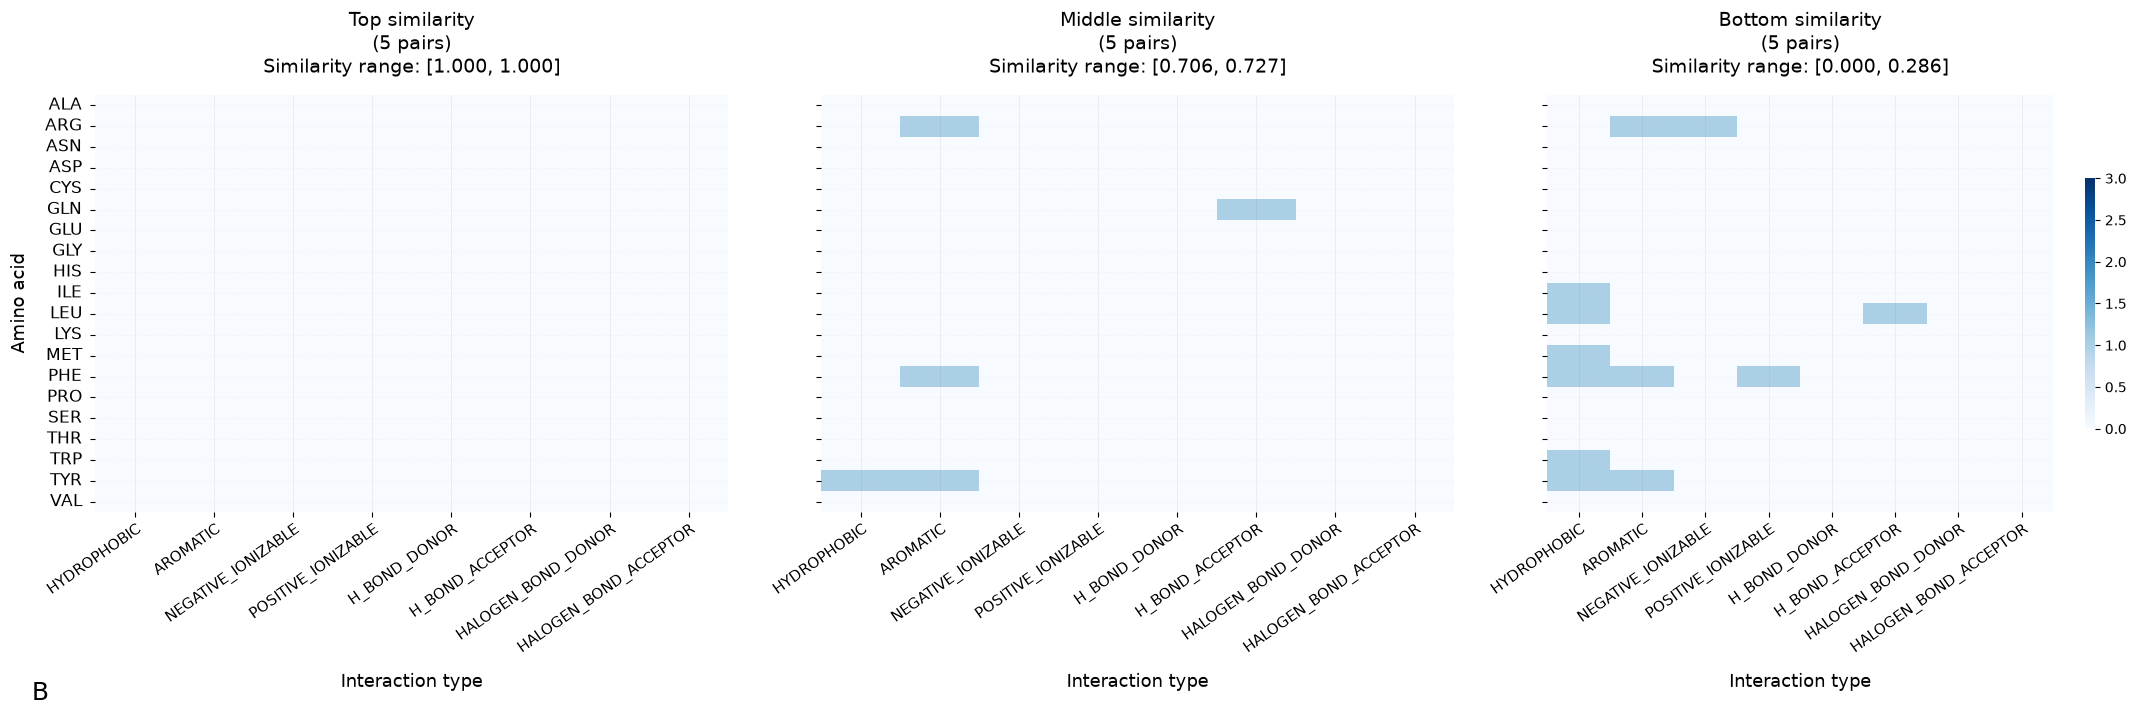

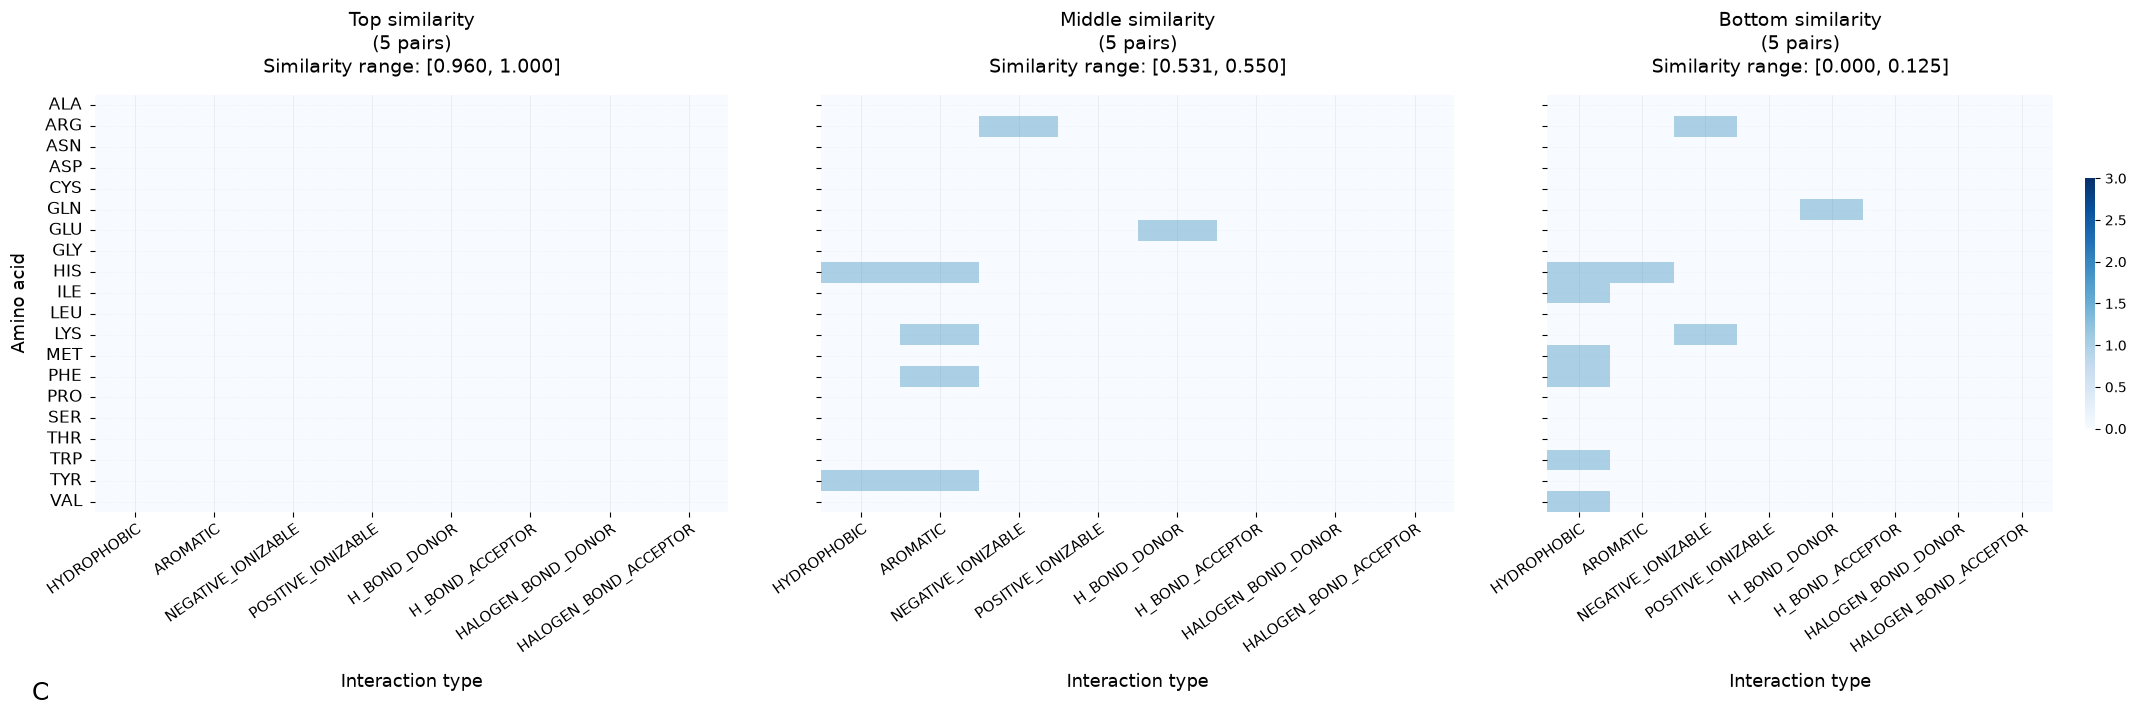

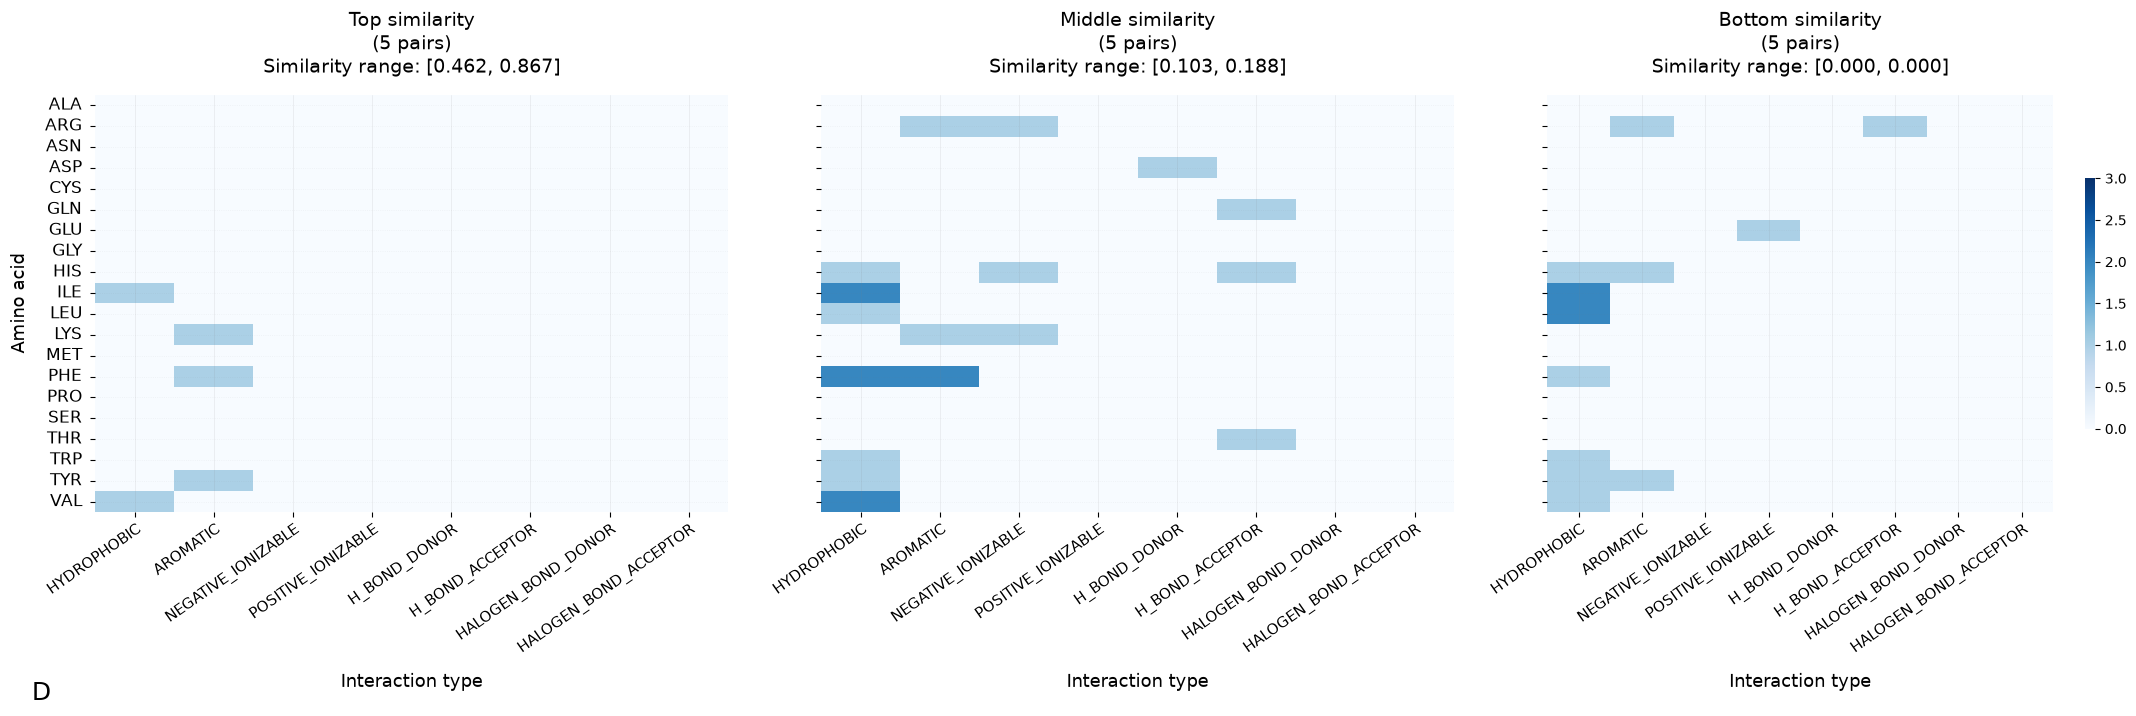

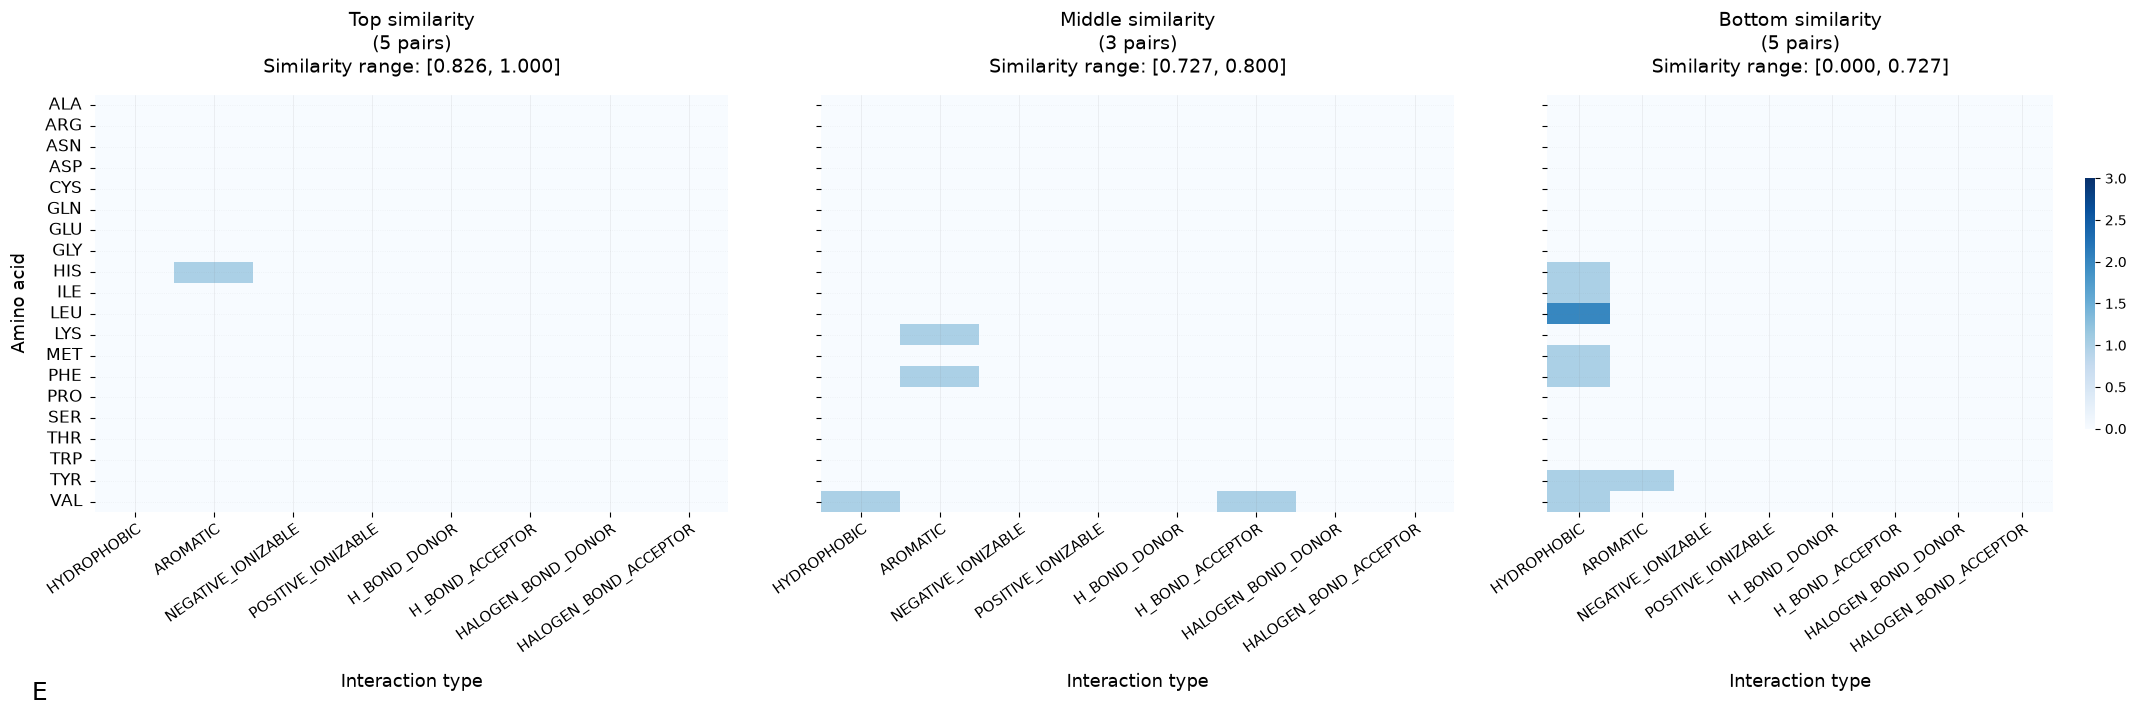

In [18]:
N_PER_GROUP = 5
CATEGORY_ORDER = ["1.1", "1.2", "1.3", "2.0"]


def parse_silirid_string(s):
    """Parse a comma-separated SILIRID count vector into a NumPy array."""
    if pd.isna(s):
        return np.array([], dtype=int)
    return np.array([int(x) for x in str(s).split(",") if str(x).strip() != ""], dtype=int)


def get_difference_matrix(subset):
    """Rows are |silirid_a − silirid_b| for each entry. Returns (n × n_slots, index list)."""
    diffs, indices = [], []
    for idx, row in subset.iterrows():
        a_vec = parse_silirid_string(row.get("closest_cross_tag_silirid_a", np.nan))
        b_vec = parse_silirid_string(row.get("closest_cross_tag_silirid_b", np.nan))
        if len(a_vec) > 0 and len(a_vec) == len(b_vec):
            diffs.append(np.abs(a_vec - b_vec))
            indices.append(idx)
    if not diffs:
        return np.empty((0, 0), dtype=int), []
    return np.stack(diffs), indices


def select_top_middle_bottom(df_subset, sim_col="closest_cross_tag_similarity", n=N_PER_GROUP):
    """n most similar, n around the median rank, n least similar."""
    valid = df_subset.dropna(subset=[sim_col]).sort_values(sim_col, ascending=False)

    n_top = min(n, len(valid))
    top = valid.iloc[:n_top].copy()
    top["similarity_group"] = "top"

    n_bottom = min(n, max(0, len(valid) - n_top))
    bottom = valid.iloc[-n_bottom:].copy() if n_bottom > 0 else valid.iloc[0:0].copy()
    bottom["similarity_group"] = "bottom"

    remaining = (
        valid.iloc[n_top : len(valid) - n_bottom]
        if len(valid) > n_top + n_bottom
        else valid.iloc[0:0]
    )
    n_mid = min(n, len(remaining))
    if n_mid > 0:
        mid_start = max(0, (len(remaining) - n_mid) // 2)
        middle = remaining.iloc[mid_start : mid_start + n_mid].copy()
    else:
        middle = remaining.copy()
    middle["similarity_group"] = "middle"
    return top, middle, bottom


required = {
    "closest_cross_tag_silirid_a",
    "closest_cross_tag_silirid_b",
    "manual_label",
    "closest_cross_tag_similarity",
}

if not required.issubset(feature_table.columns):
    raise KeyError(f"feature_table is missing columns: {sorted(required - set(feature_table.columns))}")

if {"slot_index", "amino_acid", "feature_type"}.issubset(silirid_fingerprint_slot.columns):
    slot_info = silirid_fingerprint_slot[["slot_index", "amino_acid", "feature_type"]].copy()
    slot_info = slot_info.sort_values("slot_index").reset_index(drop=True)
else:
    valid_rows = feature_table["closest_cross_tag_silirid_a"].dropna()
    n_slots = len(parse_silirid_string(valid_rows.iloc[0])) if len(valid_rows) else 0
    slot_info = pd.DataFrame({
        "slot_index": np.arange(n_slots),
        "amino_acid": ["UNK"] * n_slots,
        "feature_type": ["UNK"] * n_slots,
    })

# No more short names, use originals for both 'feature_short' and heatmaps
slot_info["feature_short"] = slot_info["feature_type"]
slot_info["amino_acid_feature"] = (
    slot_info["amino_acid"].astype(str) + "_" + slot_info["feature_type"].astype(str)
)

# Compute axis ticks for heatmaps (x = interaction type, y = amino acid)
n_slots = len(slot_info)
amino_acids = slot_info["amino_acid"].tolist()
feature_types = slot_info["feature_type"].tolist()
feature_shorts = slot_info["feature_short"].tolist()

# x axis: interaction type, y axis: amino acid
# For a slot index i: x = feature_type, y = amino_acid repeated per feature type
n_feature_types = len(set(slot_info["feature_type"]))
n_amino_acids = len(slot_info) // n_feature_types if n_feature_types > 0 else 0

# Prepare interaction type order
unique_feature_types = list(dict.fromkeys(slot_info["feature_type"].astype(str)))

# Simpler color palette: use only shades of gray (or use "Blues" for heatmap and black ticks)
simple_palette = ["black"] * len(unique_feature_types)
feature_type_color = dict(zip(unique_feature_types, simple_palette))

labels_in_table = [str(x) for x in feature_table["manual_label"].dropna().unique()]
categories = [c for c in CATEGORY_ORDER if c in labels_in_table]
categories.extend(sorted(c for c in labels_in_table if c not in categories))

legend_handles = [
    plt.Line2D(
        [0], [0], marker="s", color="w",
        markerfacecolor=feature_type_color[ft], markersize=8,
        label=f"{ft}  {ft}",
    )
    for ft in unique_feature_types
]

def matrix_to_grid(mat, n_slots, slot_info):
    if mat.size == 0 or n_slots == 0:
        return np.zeros((0, 0, 0)), [], []

    # Find amino acids and feature types order
    slot_df = slot_info.iloc[:n_slots]
    aa_list = slot_df["amino_acid"].tolist()
    ft_list = slot_df["feature_type"].tolist()

    ordered_aa = []
    ordered_ft = []
    for aa, ft in zip(aa_list, ft_list):
        if aa not in ordered_aa:
            ordered_aa.append(aa)
        if ft not in ordered_ft:
            ordered_ft.append(ft)

    n_feat = len(ordered_ft)
    n_aa = len(ordered_aa)
    grid = []
    # For each structure pair (row in mat)
    for row in mat:
        grid_row = np.full((n_aa, n_feat), np.nan)
        for i, count in enumerate(row):
            aa = aa_list[i]
            ft = ft_list[i]
            aa_idx = ordered_aa.index(aa)
            ft_idx = ordered_ft.index(ft)
            grid_row[aa_idx, ft_idx] = count
        grid.append(grid_row)
    grid = np.array(grid)
    return grid, ordered_aa, ordered_ft

# --- Calculate global min and max in integer domain across all grids ---
data_mats = []
max_val = 0  # integer maximum
for mlab in categories:
    label_subset = feature_table[feature_table["manual_label"].astype(str) == str(mlab)]
    top, middle, bottom = select_top_middle_bottom(label_subset)
    for group_name, group_df in zip(['top', 'middle', 'bottom'], [top, middle, bottom]):
        mat, ids = get_difference_matrix(group_df)
        if mat.size > 0:
            max_val = max(max_val, int(np.nanmax(mat)))
        data_mats.append(mat)
global_vmin = 0
global_vmax = max_val  # ensure integer range

# --- ADDED: helper to get min/max similarity for the group ---
def get_similarity_range(df, sim_col="closest_cross_tag_similarity"):
    if sim_col in df.columns and len(df) > 0:
        nonan = pd.to_numeric(df[sim_col], errors="coerce").dropna()
        if len(nonan) > 0:
            return float(nonan.min()), float(nonan.max())
    return None, None

# --- Figure identifiers ---
from string import ascii_uppercase
fig_identifiers = list(ascii_uppercase)

for fig_num, mlab in enumerate(categories):
    label_subset = feature_table[feature_table["manual_label"].astype(str) == str(mlab)]
    top, middle, bottom = select_top_middle_bottom(label_subset)
    fig, axes = plt.subplots(
        1, 3,
        figsize=(22, 7),
        constrained_layout=False,
        sharey=True
    )
    group_labels = ['Top similarity', 'Middle similarity', 'Bottom similarity']
    group_dfs = [top, middle, bottom]
    for j, (group_name, group_df, ax, glabel) in enumerate(zip(['top', 'middle', 'bottom'], group_dfs, axes, group_labels)):
        mat, ids = get_difference_matrix(group_df)
        n_pairs = mat.shape[0]
        n_slots_local = mat.shape[1] if n_pairs > 0 else 0

        slot_df = slot_info.iloc[:n_slots_local]
        aa_list = slot_df["amino_acid"].tolist()
        ft_list = slot_df["feature_type"].tolist()
        ordered_aa = []
        ordered_ft = []
        for aa, ft in zip(aa_list, ft_list):
            if aa not in ordered_aa:
                ordered_aa.append(aa)
            if ft not in ordered_ft:
                ordered_ft.append(ft)
        n_aa = len(ordered_aa)
        n_feat = len(ordered_ft)

        # --- get similarity range ---
        sim_min, sim_max = get_similarity_range(group_df)

        # Convert mat (n_pairs x n_slots) to (n_pairs, n_aa, n_feat)
        grid, aa_lab, ft_lab = matrix_to_grid(mat, n_slots_local, slot_info)
        if n_pairs > 0:
            # Heatmap data as integer: average, round to int
            grid_mean = np.nanmean(grid, axis=0)
            grid_mean_int = np.rint(grid_mean).astype(int)
            # REMOVE: Only annotate nonzero counts (integers) -- remove all annotation
            hm = sns.heatmap(
                grid_mean_int,
                ax=ax,
                cmap="Blues",
                cbar=(j == 2),  # only on last subplot
                annot=False,    # <- No number on block now
                fmt="",
                xticklabels=ft_lab,
                yticklabels=aa_lab,
                vmin=global_vmin,
                vmax=global_vmax,
                linewidths=0,
                cbar_kws={"shrink": 0.6, "aspect": 25} if j == 2 else None,
                square=False
            )
            ax.set_xticklabels(
                ft_lab,
                fontsize=11,
                rotation=35,
                ha="right",
                rotation_mode="anchor",
                color="black"
            )
            ax.set_yticklabels(
                aa_lab,
                fontsize=12,
                fontweight="medium",
                rotation=0,
                va="center",
                ha="right",
                color="black"
            )
            ax.tick_params(axis="y", pad=6)
        else:
            ax.text(0.5, 0.5, "No SILIRID vectors", ha="center", va="center")
            ax.axis("off")

        # --- similarity range next to title ---
        if sim_min is not None and sim_max is not None:
            sim_min_str = f"{sim_min:.3f}"
            sim_max_str = f"{sim_max:.3f}"
            sim_text = f"Similarity range: [{sim_min_str}, {sim_max_str}]"
        else:
            sim_text = "Similarity range: N/A"

        ax.set_title(
            f"{glabel}\n({len(group_df)} pairs)\n{sim_text}",
            fontsize=14, pad=16
        )
        ax.set_xlabel("Interaction type", fontsize=13, labelpad=12)
        if j == 0:
            ax.set_ylabel("Amino acid", fontsize=13, labelpad=12)
        else:
            ax.set_ylabel("")

        # Set interaction type tick colors
        for tick_label in ax.get_xticklabels():
            tick_label.set_color("black")
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.09, color='gray')
        ax.grid(axis='x', linestyle='-', linewidth=0.45, alpha=0.17, color='gray')
    # --- Add figure identifier as A, B, C, ... at bottom left ---
    fig_id = fig_identifiers[fig_num] if fig_num < len(fig_identifiers) else f'Fig.{fig_num+1}'
    axes[0].annotate(
        fig_id,
        xy=(-0.1, -0.45),
        xycoords='axes fraction',
        fontsize=18,
        ha='left',
        va='baseline',
        annotation_clip=False
    )
    fig.tight_layout(rect=[0, 0.19, 1, 0.97], w_pad=2.0, h_pad=1.0)
    plt.subplots_adjust(bottom=0.23)
    plt.show()

# Extreme cases

low RMSD with low SILIRID similarity

In [19]:
feature_table[feature_table['manual_label'] == '2'].sort_values(by='closest_cross_tag_similarity', ascending=False).head(30)

,info_file,n_structures,n_m0_structures,n_m1_structures,n_missing_or_unreadable_sdf,atom_count_unique_values,atom_count_by_file,atom_count_missing_files,atom_count_inconsistent_files,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,similarity_metric,silirid_vector_length,silirid_count_cap,manual_label,closest_cross_tag_distance
357,g001957_inchi_95048f8833_inconsistent.csv,12,4,8,0,24,interaction_6b5v_ECL_A_1001_m0.tsv=24; interac...,NaN,NaN,interaction_6b5v_ECL_B_1001_m0.tsv,interaction_8tf3_ECN_A_804_m1.tsv,20.140796,0.866667,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,2,0.133333
60,g000486_inchi_da2cf7f449_inconsistent.csv,3,2,1,0,24,interaction_2bdm_TMI_A_501_m0.tsv=24; interact...,NaN,NaN,interaction_2bdm_TMI_A_501_m0.tsv,interaction_2bdm_TMI_A_503_m1.tsv,19.664039,0.666667,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,2,0.333333
292,g001450_inchi_f30c83bcda_inconsistent.csv,2,1,1,0,15,interaction_7h1n_U4C_B_202_m0.tsv=15; interact...,NaN,NaN,interaction_7h1n_U4C_B_202_m0.tsv,interaction_7h1n_W2M_B_204_m1.tsv,9.223867,0.625000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,2,0.375000
349,g001894_inchi_059f474abc_inconsistent.csv,2,1,1,0,27,interaction_7p0o_49I_B_202_m1.tsv=27; interact...,NaN,NaN,interaction_7p0o_4OY_B_203_m0.tsv,interaction_7p0o_49I_B_202_m1.tsv,28.109760,0.500000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,2,0.500000
217,g001065_inchi_b316af5cb8_inconsistent.csv,2,1,1,0,17,interaction_7fog_W5Q_B_401_m0.tsv=17; interact...,NaN,NaN,interaction_7fog_W5Q_B_401_m0.tsv,interaction_7fog_WKH_B_402_m1.tsv,24.976431,0.461538,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,2,0.538462
218,g001075_inchi_4b7d820673_inconsistent.csv,2,1,1,0,27,interaction_5dqf_CZE_A_613_m0.tsv=27; interact...,NaN,NaN,interaction_5dqf_CZE_A_613_m0.tsv,interaction_5dqf_LCR_A_612_m1.tsv,44.435261,0.350000,"0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,2,0.650000
265,g001315_inchi_b91841c58d_inconsistent.csv,3,2,1,0,50,interaction_2wse_CLA_1_210_m0.tsv=50; interact...,NaN,NaN,interaction_2wsf_CLA_1_211_m0.tsv,interaction_2wsf_CLA_1_213_m1.tsv,44.175862,0.300000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,2,0.700000
37,g000383_inchi_db27c21bb6_inconsistent.csv,2,1,1,0,24,interaction_4a07_AZ7_A_600_m1.tsv=24; interact...,NaN,NaN,interaction_4a07_AZ7_A_700_m0.tsv,interaction_4a07_AZ7_A_600_m1.tsv,35.747258,0.230769,"0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,2,0.769231
82,g000576_inchi_7f2de80634_inconsistent.csv,4,3,1,0,19,interaction_7jwn_9KL_A_2304_m0.tsv=19; interac...,NaN,NaN,interaction_7jwn_9KL_A_2309_m0.tsv,interaction_7jwn_JGE_A_2307_m1.tsv,12.611379,0.200000,"0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,2,0.800000
170,g000949_inchi_4a97d65d17_inconsistent.csv,4,2,2,0,15,interaction_7b61_SYQ_A_502_m0.tsv=15; interact...,NaN,NaN,interaction_7b61_SYQ_B_504_m0.tsv,interaction_7b61_T3Z_B_501_m1.tsv,16.711322,0.187500,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,2,0.812500


In [20]:
feature_table[feature_table['manual_label'] == '1.3'].sort_values(by='closest_cross_tag_similarity', ascending=False).head(30)

,info_file,n_structures,n_m0_structures,n_m1_structures,n_missing_or_unreadable_sdf,atom_count_unique_values,atom_count_by_file,atom_count_missing_files,atom_count_inconsistent_files,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,similarity_metric,silirid_vector_length,silirid_count_cap,manual_label,closest_cross_tag_distance
109,g000668_inchi_2dd5f14064_inconsistent.csv,2,1,1,0,39,interaction_6u98_Q2D_A_301_m1.tsv=39; interact...,NaN,NaN,interaction_6u9a_Q2A_A_301_m0.tsv,interaction_6u98_Q2D_A_301_m1.tsv,4.430346,1.000000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.3,0.000000
287,g001409_inchi_1919686b8d_inconsistent.csv,2,1,1,0,30,interaction_3fmh_533_A_361_m1.tsv=30; interact...,NaN,NaN,interaction_3fmk_FMK_A_361_m0.tsv,interaction_3fmh_533_A_361_m1.tsv,2.494790,1.000000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.3,0.000000
141,g000800_inchi_bf09930798_inconsistent.csv,14,2,12,0,34,interaction_6w63_X77_A_401_m1.tsv=34; interact...,NaN,NaN,interaction_8p5c_9M5_A_401_m0.tsv,interaction_7phz_X77_B_401_m1.tsv,3.984642,1.000000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.3,0.000000
322,g001752_inchi_49ebacec78_inconsistent.csv,15,5,10,0,16,interaction_8q1m_ILR_A_301_m1.tsv=16; interact...,NaN,NaN,interaction_8qtl_WSP_A_301_m0.tsv,interaction_8qx2_ILR_B_301_m1.tsv,2.392444,1.000000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.3,0.000000
97,g000623_inchi_b69e2fa9f6_inconsistent.csv,8,4,4,0,30,interaction_6oju_D96_A_601_m1.tsv=30; interact...,NaN,NaN,interaction_6ojv_2XB_B_601_m0.tsv,interaction_6oju_D96_C_601_m1.tsv,2.927835,0.960000,"0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...","0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...",structure_silirid_similarity,160,3,1.3,0.040000
326,g001766_inchi_66ada768a2_inconsistent.csv,4,2,2,0,19,interaction_7xvz_I1D_A_601_m0.tsv=19; interact...,NaN,NaN,interaction_7xvz_I1D_B_601_m0.tsv,interaction_7xwp_I1I_B_601_m1.tsv,6.790125,0.958333,"0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.3,0.041667
343,g001852_inchi_7bd361cc89_inconsistent.csv,2,1,1,0,29,interaction_6yuh_POW_A_503_m1.tsv=29; interact...,NaN,NaN,interaction_7bj1_QKT_A_502_m0.tsv,interaction_6yuh_POW_A_503_m1.tsv,6.320073,0.947368,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.3,0.052632
126,g000718_inchi_773ebfa2e3_inconsistent.csv,6,4,2,0,28,interaction_3sgy_06W_A_168_m1.tsv=28; interact...,NaN,NaN,interaction_4xe6_06U_X_201_m0.tsv,interaction_3sgy_06W_A_168_m1.tsv,2.844855,0.894737,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.3,0.105263
202,g001036_inchi_1b551103cd_inconsistent.csv,8,4,4,0,27,interaction_3jwu_J11_A_800_m0.tsv=27; interact...,NaN,NaN,interaction_3jwu_J11_B_800_m0.tsv,interaction_3jwv_J14_B_800_m1.tsv,1.705003,0.888889,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.3,0.111111
187,g001015_inchi_4659f7c497_inconsistent.csv,3,2,1,0,29,interaction_6bgv_DQG_A_601_m0.tsv=29; interact...,NaN,NaN,interaction_6bgv_DQG_A_601_m0.tsv,interaction_6bh0_DO1_A_601_m1.tsv,2.622697,0.875000,"0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,...",structure_silirid_similarity,160,3,1.3,0.125000
